# Medical Insurance Charges — Exploratory Data Analysis

**Dataset:** Medical Cost Personal Dataset (~1,500 records)  
**Columns:** age, sex, bmi, children, smoker, region, charges  
**Objective:** Understand the distribution, data quality, and key drivers of medical insurance charges through structured EDA.

---

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

Matplotlib is building the font cache; this may take a moment.


## 2. Load Dataset

In [2]:
mdcost = pd.read_csv('Medical_Cost.csv')
print('Shape:', mdcost.shape)
mdcost.head()

Shape: (1520, 7)


,age,sex,bmi,children,smoker,region,charges
0,56.0,female,29.8,0.0,yes,northwest,50698.451831
1,46.0,male,31.6,0.0,no,northeast,20044.660453
2,32.0,female,34.8,3.0,no,northwest,22275.226425
3,60.0,male,37.4,3.0,no,northwest,29537.540433
4,25.0,female,29.3,5.0,yes,southwest,42777.694040


## 3. Initial Data Inspection

We start by reviewing the structure, data types, and basic statistics to understand what we're working with.

In [3]:
mdcost.info()  # Column data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1490 non-null   float64
 1   sex       1520 non-null   str    
 2   bmi       1490 non-null   float64
 3   children  1489 non-null   float64
 4   smoker    1520 non-null   str    
 5   region    1520 non-null   str    
 6   charges   1520 non-null   float64
dtypes: float64(4), str(3)
memory usage: 83.3 KB


In [4]:
mdcost.describe()  # Statistical summary of numeric columns

,age,bmi,children,charges
count,1490.000000,1490.000000,1489.000000,1520.000000
mean,41.282550,30.861544,2.533244,25687.129568
std,13.495368,7.982498,1.694116,10327.490065
min,18.000000,12.400000,0.000000,5008.078549
25%,29.000000,26.300000,1.000000,18349.539908
50%,42.000000,30.600000,3.000000,22915.182079
75%,53.000000,34.575000,4.000000,29560.925389
max,64.000000,91.000000,5.000000,55721.990643


## 4. Data Cleaning

### 4.1 Duplicate Records
We check for and remove exact duplicate rows to ensure each record represents a unique individual.

In [5]:
print('Duplicate rows found:', mdcost.duplicated().sum())
mdcost[mdcost.duplicated(keep=False)]  # View all copies of duplicate records

Duplicate rows found: 20


,age,sex,bmi,children,smoker,region,charges
0,56.0,female,29.8,0.0,yes,northwest,50698.451831
1,46.0,male,31.6,0.0,no,northeast,20044.660453
2,32.0,female,34.8,3.0,no,northwest,22275.226425
3,60.0,male,37.4,3.0,no,northwest,29537.540433
4,25.0,female,29.3,5.0,yes,southwest,42777.694040
5,38.0,male,30.6,2.0,yes,northwest,42444.678364
6,56.0,male,30.1,1.0,yes,northwest,46682.462106
7,36.0,female,26.7,3.0,no,southwest,20107.577177
8,40.0,male,25.4,2.0,no,southwest,17006.010197
9,28.0,female,16.4,5.0,no,northeast,9098.806830


In [6]:
mdcost.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', mdcost.shape)

Shape after removing duplicates: (1500, 7)


### 4.2 Missing Values

We identify columns with null values and decide on the appropriate imputation strategy for each.

In [7]:
mdcost.isnull().sum()  # Count of missing values per column

age         30
sex          0
bmi         30
children    30
smoker       0
region       0
charges      0
dtype: int64

#### 4.2.1 `age` Column

The `age` column has 30 missing values. We first inspect its distribution to decide between mean and median imputation.

Mean  : 41.29
Median: 42.0
Skew  : -0.065


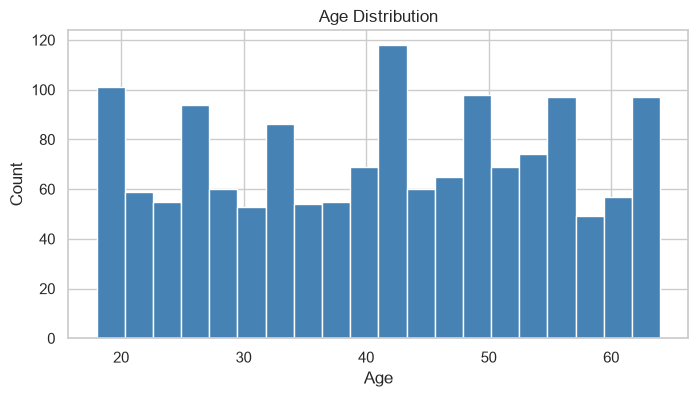

In [8]:
print('Mean  :', mdcost['age'].mean().round(2))
print('Median:', mdcost['age'].median())
print('Skew  :', mdcost['age'].skew().round(3))

mdcost['age'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Observation:** Age is nearly symmetric (skew ≈ 0.05), so mean and median are very close.  
Mean imputation is appropriate here. After filling, we cast to `int` since age is a whole number.

In [9]:
mdcost['age'] = mdcost['age'].fillna(mdcost['age'].mean())
mdcost['age'] = mdcost['age'].astype(int)
print('Null values in age after imputation:', mdcost['age'].isnull().sum())

Null values in age after imputation: 0


#### 4.2.2 `children` Column

`children` is a count variable. We inspect its distribution before imputation.

In [10]:
print('Value Counts (sorted):')
print(mdcost['children'].value_counts(dropna=False).sort_index())
print()
print('Mean  :', mdcost['children'].mean().round(2))
print('Median:', mdcost['children'].median())
print('Mode  :', mdcost['children'].mode()[0])

Value Counts (sorted):
children
0.0    230
1.0    242
2.0    249
3.0    251
4.0    249
5.0    249
NaN     30
Name: count, dtype: int64

Mean  : 2.54
Median: 3.0
Mode  : 3.0


**Observation:** The distribution is right-skewed — most policyholders have 0 children.  
Median (0) is a better imputation choice than mean (1.09) to avoid introducing a non-integer value.  
We cast to `int` since a fractional count of children is meaningless.

In [11]:
mdcost['children'] = mdcost['children'].fillna(mdcost['children'].median())
mdcost['children'] = mdcost['children'].astype(int)
print('Null values in children after imputation:', mdcost['children'].isnull().sum())

Null values in children after imputation: 0


#### 4.2.3 `bmi` Column

BMI (Body Mass Index) is a continuous variable. We check its distribution and outliers.

Mean  : 30.89
Median: 30.6
Skew  : 2.588


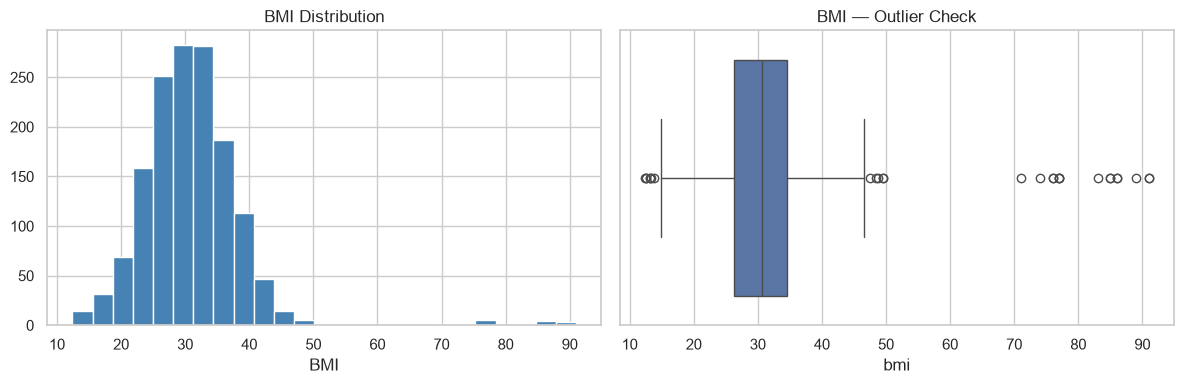

BMI valid range (IQR method): 13.85 – 47.05
Outlier rows: 27


In [12]:
print('Mean  :', mdcost['bmi'].mean().round(2))
print('Median:', mdcost['bmi'].median())
print('Skew  :', mdcost['bmi'].skew().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mdcost['bmi'].hist(ax=axes[0], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI')
sns.boxplot(x=mdcost['bmi'], ax=axes[1])
axes[1].set_title('BMI — Outlier Check')
plt.tight_layout()
plt.show()

# IQR-based outlier detection
Q1 = mdcost['bmi'].quantile(0.25)
Q3 = mdcost['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = mdcost[(mdcost['bmi'] < lower) | (mdcost['bmi'] > upper)]
print(f'BMI valid range (IQR method): {lower:.2f} – {upper:.2f}')
print(f'Outlier rows: {outliers.shape[0]}')

**Observation:** BMI is slightly right-skewed (skew ≈ 0.28). The boxplot shows some high-end outliers, but these likely represent genuinely obese individuals — clinically valid data points.  
We use **median imputation** (robust to skew and outliers) rather than mean.  
Outliers are **retained** since they are medically plausible and relevant for charge analysis.

In [13]:
mdcost['bmi'] = mdcost['bmi'].fillna(mdcost['bmi'].median())
print('Null values in bmi after imputation:', mdcost['bmi'].isnull().sum())

Null values in bmi after imputation: 0


### 4.3 Post-Cleaning Summary

In [14]:
print('Final shape:', mdcost.shape)
print()
mdcost.isnull().sum()

Final shape: (1500, 7)



age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 5. Exploratory Data Analysis (EDA)

Now that the data is clean, we analyse the distribution of each feature and its relationship with insurance charges.

### 5.1 Overview — All Features

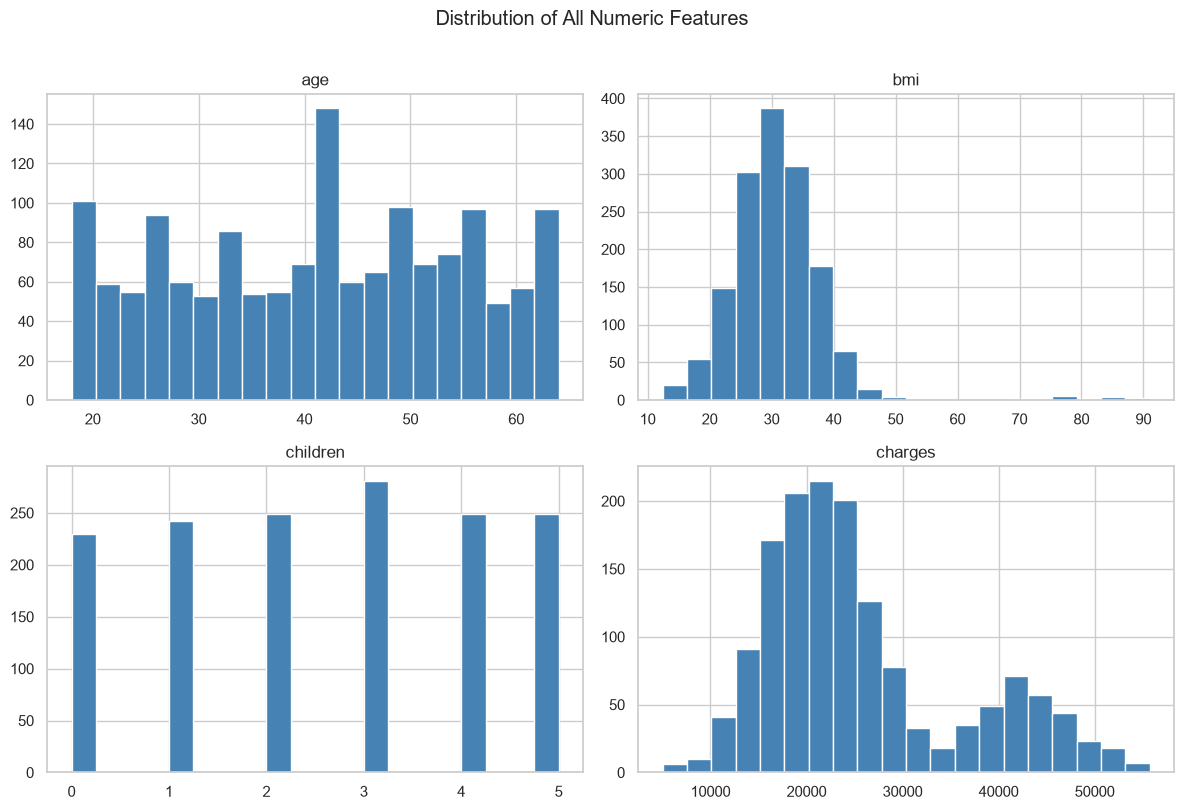

In [15]:
mdcost.hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of All Numeric Features', y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Univariate Analysis

We examine each numeric column individually for distribution shape and spread.

#### Age

count    1500.00
mean       41.28
std        13.37
min        18.00
25%        30.00
50%        41.50
75%        52.00
max        64.00
Name: age, dtype: float64


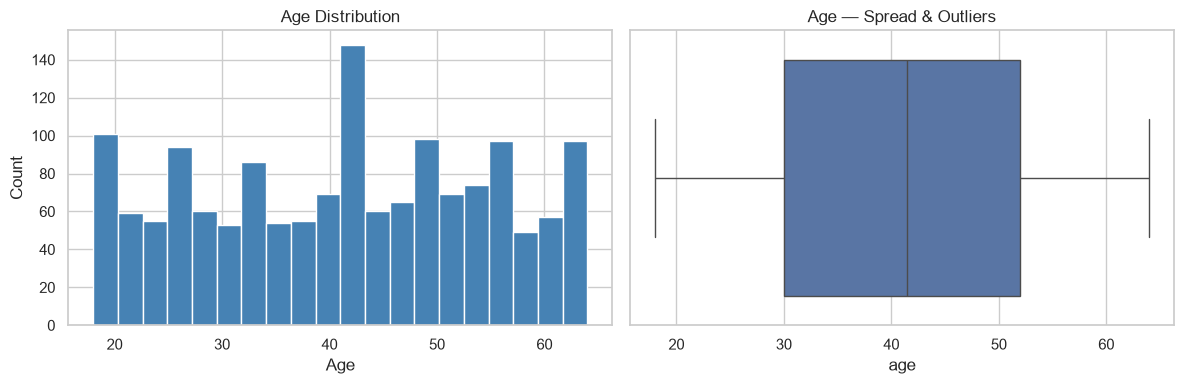

In [16]:
print(mdcost['age'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mdcost['age'].hist(ax=axes[0], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
sns.boxplot(x=mdcost['age'], ax=axes[1])
axes[1].set_title('Age — Spread & Outliers')
plt.tight_layout()
plt.show()

**Observation:** Age is fairly uniformly distributed between 18 and 64, with no significant outliers. The dataset covers a broad adult age range.

#### BMI

count    1500.00
mean       30.88
std         7.93
min        12.40
25%        26.40
50%        30.60
75%        34.50
max        91.00
Name: bmi, dtype: float64


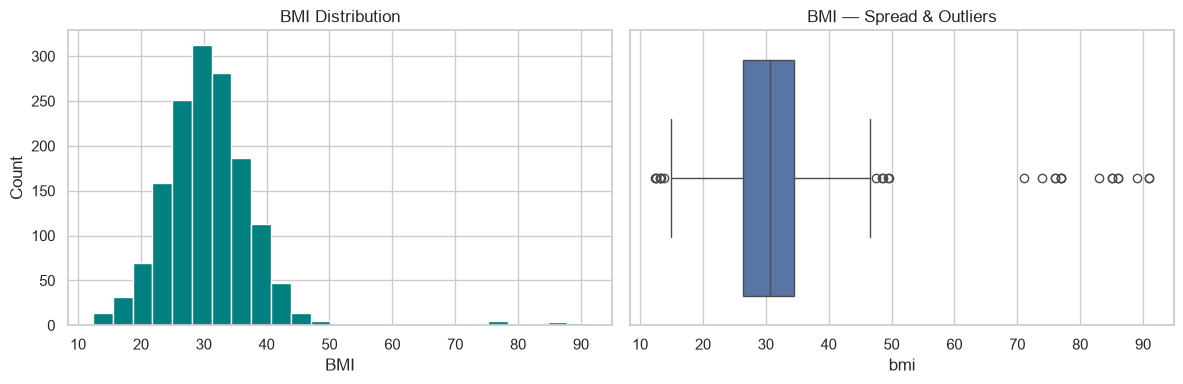

In [17]:
print(mdcost['bmi'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mdcost['bmi'].hist(ax=axes[0], bins=25, color='teal', edgecolor='white')
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')
sns.boxplot(x=mdcost['bmi'], ax=axes[1])
axes[1].set_title('BMI — Spread & Outliers')
plt.tight_layout()
plt.show()

**Observation:** BMI is approximately normally distributed with a mean around 30.6 (the overweight/obese threshold). A small number of high-end outliers exist but are clinically valid.

#### Children

count    1500.00
mean        2.55
std         1.68
min         0.00
25%         1.00
50%         3.00
75%         4.00
max         5.00
Name: children, dtype: float64


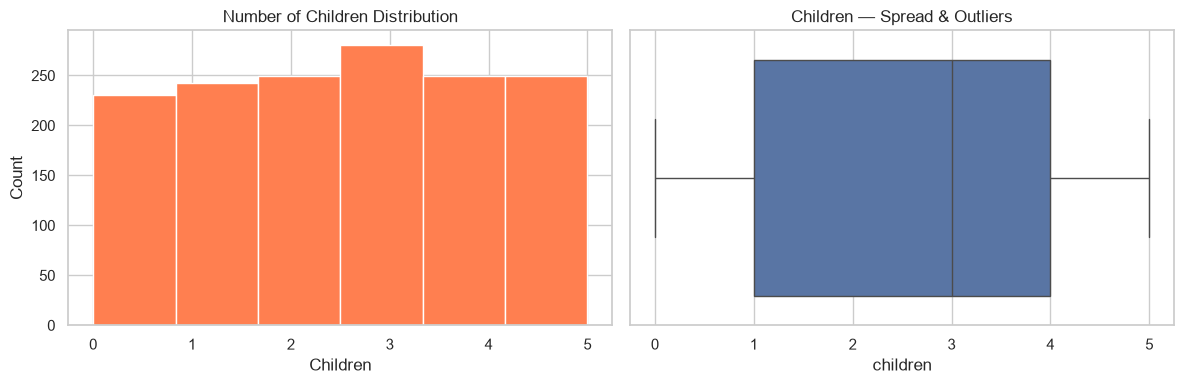

In [18]:
print(mdcost['children'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mdcost['children'].hist(ax=axes[0], bins=6, color='coral', edgecolor='white')
axes[0].set_title('Number of Children Distribution')
axes[0].set_xlabel('Children')
axes[0].set_ylabel('Count')
sns.boxplot(x=mdcost['children'], ax=axes[1])
axes[1].set_title('Children — Spread & Outliers')
plt.tight_layout()
plt.show()

**Observation:** Most policyholders have 0 children (right-skewed). Having 5 children is relatively rare and appears as a high outlier.

#### Charges (Target Variable)

count     1500.00
mean     25652.08
std      10306.76
min       5008.08
25%      18341.89
50%      22915.18
75%      29518.63
max      55721.99
Name: charges, dtype: float64


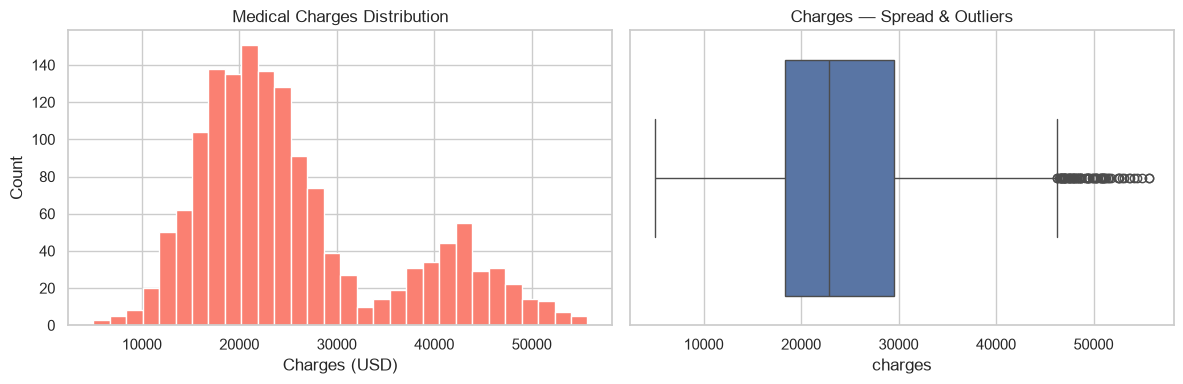

In [19]:
print(mdcost['charges'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mdcost['charges'].hist(ax=axes[0], bins=30, color='salmon', edgecolor='white')
axes[0].set_title('Medical Charges Distribution')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Count')
sns.boxplot(x=mdcost['charges'], ax=axes[1])
axes[1].set_title('Charges — Spread & Outliers')
plt.tight_layout()
plt.show()

**Observation:** Charges are heavily right-skewed. Most policyholders have charges in the \$1,000–\$15,000 range, but a notable cluster of high-cost individuals exists (likely smokers or those with high BMI), pulling the mean (\~\$13,270) well above the median (\~\$9,382).

### 5.3 Bivariate Analysis — Numeric vs Charges

We explore how each continuous feature relates to insurance charges.

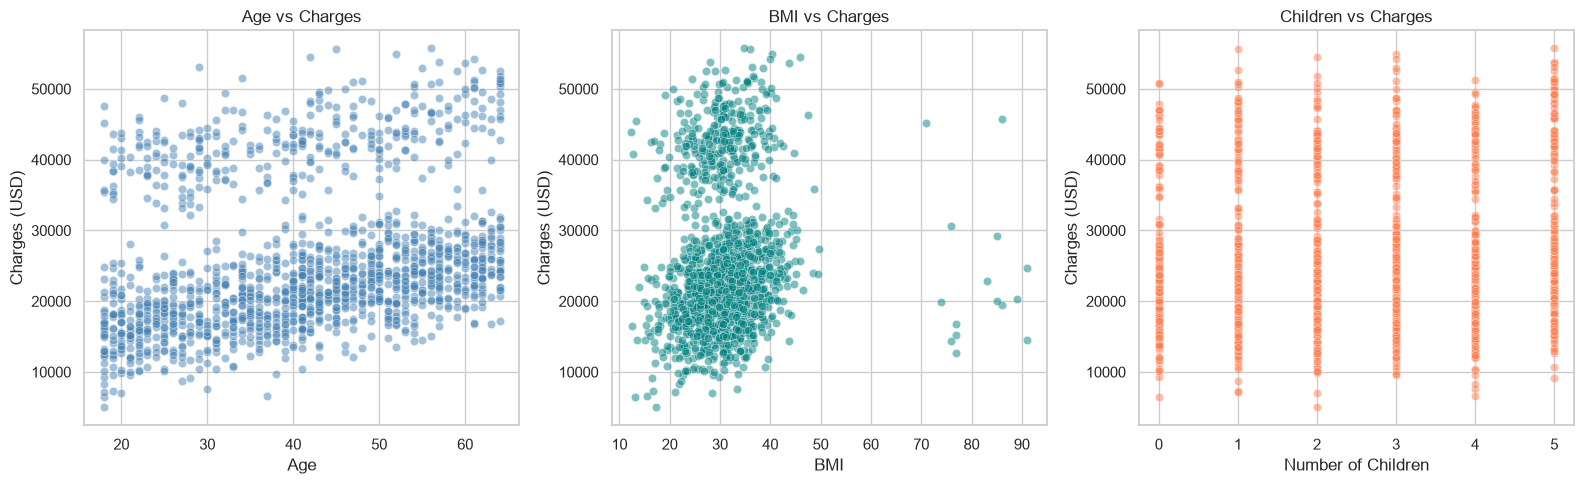

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(x=mdcost['age'], y=mdcost['charges'], ax=axes[0], alpha=0.5, color='steelblue')
axes[0].set_title('Age vs Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges (USD)')

sns.scatterplot(x=mdcost['bmi'], y=mdcost['charges'], ax=axes[1], alpha=0.5, color='teal')
axes[1].set_title('BMI vs Charges')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges (USD)')

sns.scatterplot(x=mdcost['children'], y=mdcost['charges'], ax=axes[2], alpha=0.5, color='coral')
axes[2].set_title('Children vs Charges')
axes[2].set_xlabel('Number of Children')
axes[2].set_ylabel('Charges (USD)')

plt.tight_layout()
plt.show()

**Observations:**
- **Age vs Charges:** Positive trend — older individuals tend to incur higher charges. Three distinct charge bands are visible, likely separating smokers, high-BMI, and healthy individuals.
- **BMI vs Charges:** There is a noticeable split above BMI ≈ 30 where a cluster of very high charges appears — strongly suggestive of smoker overlap.
- **Children vs Charges:** No clear linear trend; number of dependents does not strongly drive charges.

### 5.4 Bivariate Analysis — Categorical vs Charges

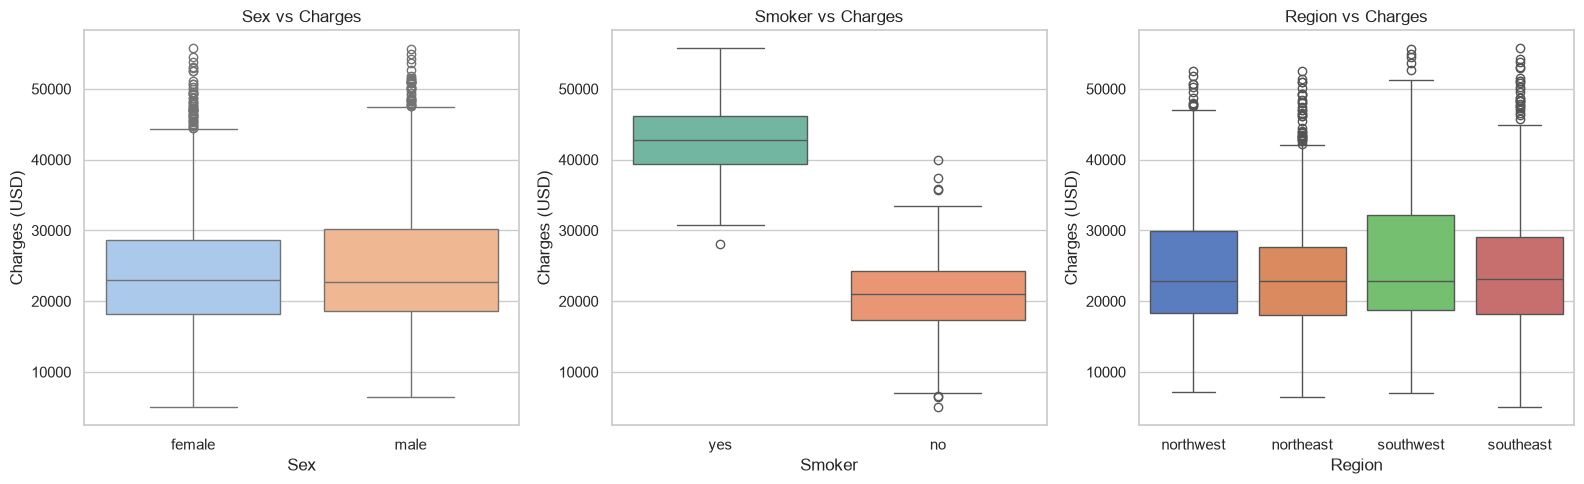

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='sex', y='charges', hue='sex', data=mdcost, ax=axes[0], palette='pastel', legend=False)
axes[0].set_title('Sex vs Charges')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Charges (USD)')

sns.boxplot(x='smoker', y='charges', hue='smoker', data=mdcost, ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Smoker vs Charges')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Charges (USD)')

sns.boxplot(x='region', y='charges', hue='region', data=mdcost, ax=axes[2], palette='muted', legend=False)
axes[2].set_title('Region vs Charges')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Charges (USD)')

plt.tight_layout()
plt.show()

**Observations:**
- **Sex:** Males and females have very similar charge distributions. Gender is not a major cost differentiator in this dataset.
- **Smoker:** This is the single most impactful feature. Smokers incur dramatically higher charges — the median charge for smokers is roughly 3–4× that of non-smokers, with a much wider spread.
- **Region:** Charges are broadly similar across all four US regions (northeast, northwest, southeast, southwest), with the southeast showing a slightly higher spread — possibly correlated with higher average BMI in that region.

### 5.5 Multivariate Analysis — BMI × Smoker interaction on Charges

Since both BMI and smoking showed notable signals individually, we visualise their combined effect.

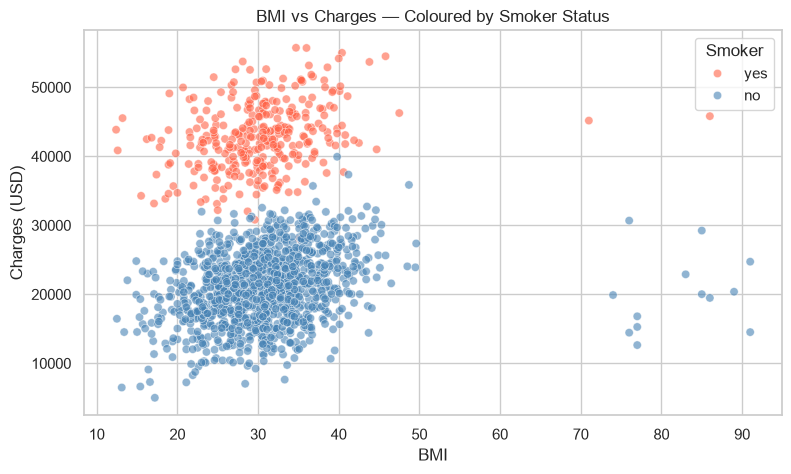

In [22]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=mdcost,
                palette={'yes': 'tomato', 'no': 'steelblue'}, alpha=0.6)
plt.title('BMI vs Charges — Coloured by Smoker Status')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.legend(title='Smoker')
plt.show()

**Observation:** The chart reveals two very distinct clusters:
- **Non-smokers (blue):** Charges are low to moderate regardless of BMI.
- **Smokers (red):** Charges are significantly higher across all BMI values, and increase sharply when BMI exceeds ~30 (the obese threshold).

This interaction between smoking and BMI is the strongest pattern in the dataset.

### 5.6 Correlation Heatmap

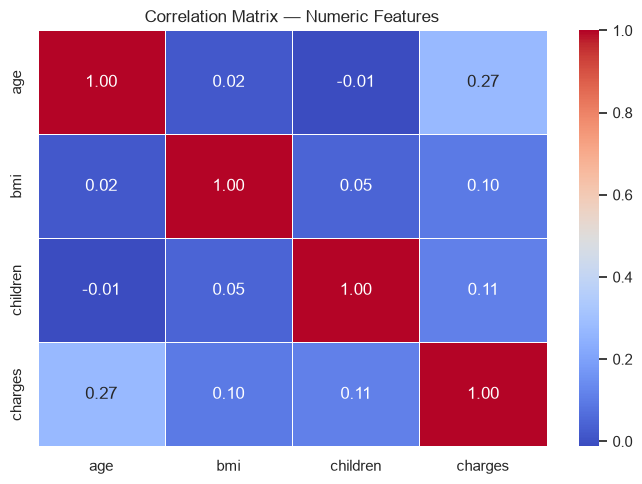

In [23]:
corr = mdcost.corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

**Observation:** 
- `age` has the highest positive correlation with `charges` (~0.30) among numeric features.
- `bmi` shows a moderate correlation (~0.20), but this is amplified significantly for smokers (as seen in Section 5.5).
- `children` has minimal correlation with charges.
- No strong multicollinearity exists between the independent variables.

## 6. Key Insights & Summary

| # | Insight |
|---|---------|
| 1 | **Smoking is the dominant cost driver.** Smokers pay 3–4× more in charges compared to non-smokers. |
| 2 | **Age has a consistent positive effect** on charges — older policyholders incur higher costs. |
| 3 | **BMI alone is moderately correlated** with charges, but its impact is amplified greatly for smokers (obese smokers are the highest-cost group). |
| 4 | **Gender and region are weak predictors** — charge distributions are similar across sex and all four regions. |
| 5 | **Charges are right-skewed**, driven by a high-cost minority — a log transformation would be recommended before feeding this data into a regression model. |
| 6 | **Data quality issues found and resolved:** 1 duplicate row removed; missing values in `age`, `children`, and `bmi` imputed using mean/median strategies based on skewness. |

---
*Analysis performed using Python · pandas · matplotlib · seaborn*